In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Part A: Data Preparation

np.random.seed(42)

# Load the data
df = pd.read_csv("data.csv", sep = ";")

# Separate the input features and target labels
X = df.drop("Target", axis = 1).values
y = df["Target"].values

# Encode the labels to integers
label_with_encode = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
y_encoded = np.array([label_with_encode[label] for label in y])

# One-hot encode the labels
def one_hot_encode(y, num_labels = 3):
    one_hot_encoded_labels = np.zeros((len(y), num_labels))
    for i, label in enumerate(y):
        one_hot_encoded_labels[i, label] = 1
        
    return one_hot_encoded_labels

y_one_hot_encoded = one_hot_encode(y_encoded)

# Split into train/test (80/20), then train/val (80/20 of training set)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_one_hot_encoded, test_size = 0.2, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size = 0.2, random_state = 42)

# Apply StandardScaler to the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
# Part B: Neural Network Architecture

# Activation Functions
def ReLU(z):
   return np.maximum(0, z)

def softmax(z):
    # Find the maximum value in each row
    max_values = np.max(z, axis = 1, keepdims = True)
    
    # Subtract the maximum values for numerical stability
    z = z - max_values

    # Apply an exponent to each element
    exp_z = np.exp(z)
    
    # Sum the exponents across each row
    sum_exp = np.sum(exp_z, axis = 1, keepdims = True)
    
    # Normalize to get probabilities
    return exp_z / sum_exp 

# Weight initialization
def initialize_parameters(init_type, layer_sizes):
    params = {}
    
    for i in range(1, len(layer_sizes)):
        fan_in = layer_sizes[i - 1]
        fan_out = layer_sizes[i]
        
        if init_type == "xavier":
            limit = np.sqrt(6.0 / (fan_in + fan_out))
            params[f"W{i}"] = np.random.uniform(-limit, limit, size = (fan_in, fan_out))
            
        elif init_type == "he":
            limit = np.sqrt(6.0 / fan_in)
            params[f"W{i}"] = np.random.uniform(-limit, limit, size = (fan_in, fan_out))
            
        else:  # Small Random
            params[f"W{i}"] = np.random.normal(0, 0.01, size = (fan_in, fan_out))
            
        params[f"b{i}"] = np.zeros((1, fan_out))
        
    return params

# Forward Propagation
def forward_propagation(X, params, dropout_rate, training):
    forward_cache = {"A0": X}
    num_layers = len(params) // 2

    # Hidden layers
    for i in range(1, num_layers):
        Z = forward_cache[f"A{i - 1}"] @ params[f"W{i}"] + params[f"b{i}"]
        A = ReLU(Z)
        
        # Dropout (only during training)
        if training and dropout_rate > 0:
            mask = np.random.binomial(1, 1 - dropout_rate, size = A.shape)
            A *= mask
            forward_cache[f"mask{i}"] = mask
    
        forward_cache[f"Z{i}"] = Z
        forward_cache[f"A{i}"] = A
    
    # Output layer (softmax)
    A_prev = forward_cache[f"A{num_layers - 1}"]
    Z = A_prev @ params[f"W{num_layers}"] + params[f"b{num_layers}"]
    A = softmax(Z)
    
    forward_cache[f"Z{num_layers}"] = Z
    forward_cache[f"A{num_layers}"] = A
    
    return A, forward_cache

# Cross-entropy loss
def compute_loss(y_pred, y_true):
    n = y_true.shape[0]

    # avoid log(0)
    log_probs = np.log(y_pred + 1e-8)
    loss = -np.sum(y_true * log_probs)
    
    return loss / n

# Backward Propagation
def backward_propagation(y_pred, y_true, params, cache, dropout_rate):
    gradients = {}
    n = y_true.shape[0]
    num_layers = len(params) // 2
    
    # Output layer gradient (softmax + cross-entropy)
    dZ = y_pred - y_true
    
    # Backpropagate through layers
    for i in range(num_layers, 0, -1):

        A_prev = cache[f"A{i-1}"]
        
        # Gradients for the parameters
        gradients[f"dW{i}"] = (A_prev.T @ dZ) / n
        gradients[f"db{i}"] = np.sum(dZ, axis = 0, keepdims = True) / n
        
        # Move the gradient backward if it is not the input layer
        if i > 1:
            W = params[f"W{i}"]
            dA_prev = dZ @ W.T

            # ReLU backward
            dZ = dA_prev * (cache[f"Z{i - 1}"] > 0)

            # Dropout backward (only if it is used)
            if dropout_rate > 0:
                mask_key = f"mask{i - 1}"
                if mask_key in cache:
                    dZ *= cache[mask_key]

    return gradients

# Update Weights
def update_parameters(params, gradients, lr):
    num_layers = len(params) // 2
    for i in range(1, num_layers + 1):
        params[f"W{i}"] -= lr * gradients[f"dW{i}"]
        params[f"b{i}"] -= lr * gradients[f"db{i}"]
    
    return params      

# Predict class labels
def predict(X, params):
    y_pred, _ = forward_propagation(X, params, 0.0, False)
    return np.argmax(y_pred, axis = 1)

# Accuracy
def accuracy(y_pred, y_true):
    return np.mean(y_pred == np.argmax(y_true, axis = 1))

In [4]:
# Training loop: Batch, Stochastic, and Mini-Batch Gradient Descent

def train(X_train, y_train, X_val, y_val, layer_sizes, init_type, lr, epochs, batch_size, dropout_rate):
    np.random.seed(42)
    params = initialize_parameters(init_type, layer_sizes)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    n = X_train.shape[0]
    
    for epoch in range(epochs):
        # Shuffle the training data
        indices = np.random.permutation(n)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        # Batch Gradient Descent
        if batch_size == n:
            y_pred, cache = forward_propagation(X_shuffled, params, dropout_rate, True)
            gradients = backward_propagation(y_pred, y_shuffled, params, cache, dropout_rate)
            params = update_parameters(params, gradients, lr)
            
        # Stochastic Gradient Descent
        elif batch_size == 1:
            for i in range(n):
                X_batch = X_shuffled[i:i + 1]
                y_batch = y_shuffled[i:i + 1]
                y_pred, cache = forward_propagation(X_batch, params, dropout_rate, True)
                gradients = backward_propagation(y_pred, y_batch, params, cache, dropout_rate)
                params = update_parameters(params, gradients, lr)
        
        # Mini-batch Gradient Descent
        else:
            for start in range(0, n, batch_size):
                X_batch = X_shuffled[start:start + batch_size]
                y_batch = y_shuffled[start:start + batch_size]
                y_pred, cache = forward_propagation(X_batch, params, dropout_rate, True)
                gradients = backward_propagation(y_pred, y_batch, params, cache, dropout_rate)
                params = update_parameters(params, gradients, lr)
        
        # Track the loss and accuracy
        train_pred, _ = forward_propagation(X_train, params, 0.0, False)
        val_pred, _ = forward_propagation(X_val, params, 0.0, False)
        
        train_losses.append(compute_loss(train_pred, y_train))
        val_losses.append(compute_loss(val_pred, y_val))
        train_accs.append(accuracy(predict(X_train, params), y_train))
        val_accs.append(accuracy(predict(X_val, params), y_val))
    
    return params, train_losses, val_losses, train_accs, val_accs

In [5]:
# Plot the training and validation loss and accuracy
def plot_loss_and_acc(train_losses, val_losses, train_accs, val_accs, title):
    epochs = range(1, len(train_losses) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))

    axes[0].plot(epochs, train_losses, label = "Training Loss")
    axes[0].plot(epochs, val_losses, label = "Validation Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    
    axes[1].plot(epochs, train_accs, label = "Training Accuracy")
    axes[1].plot(epochs, val_accs, label = "Validation Accuracy")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

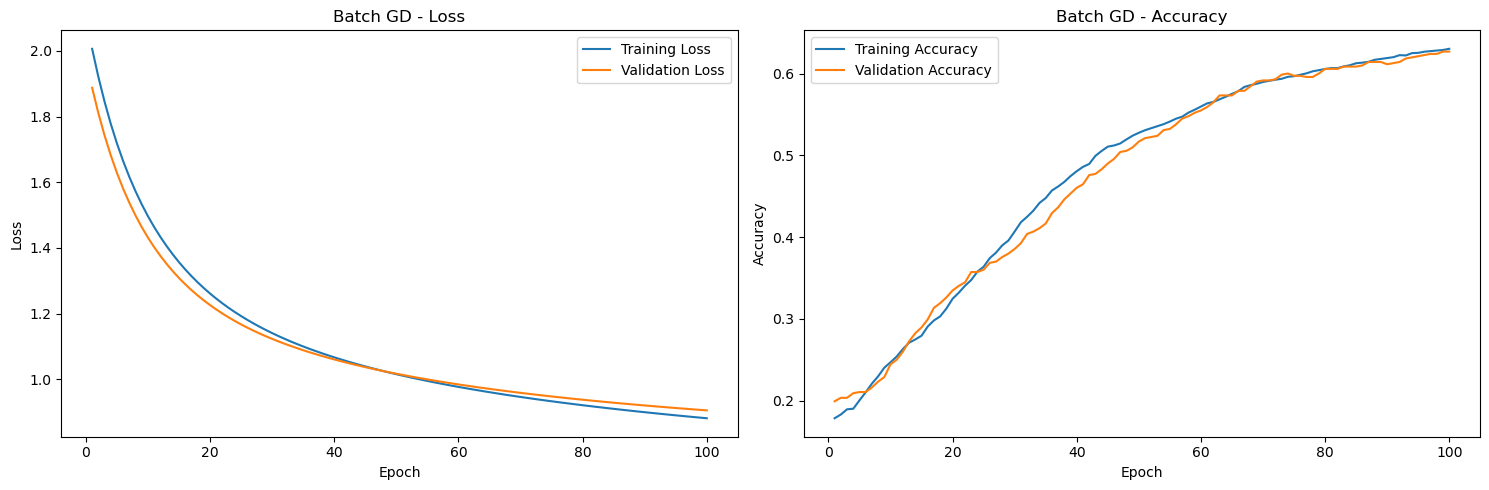

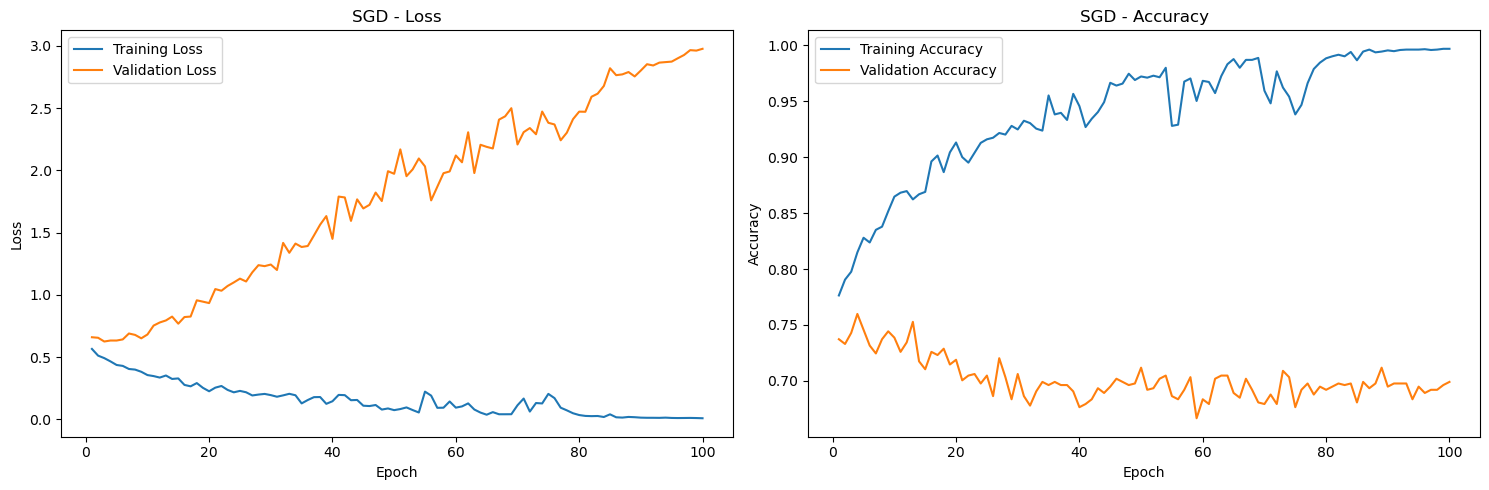

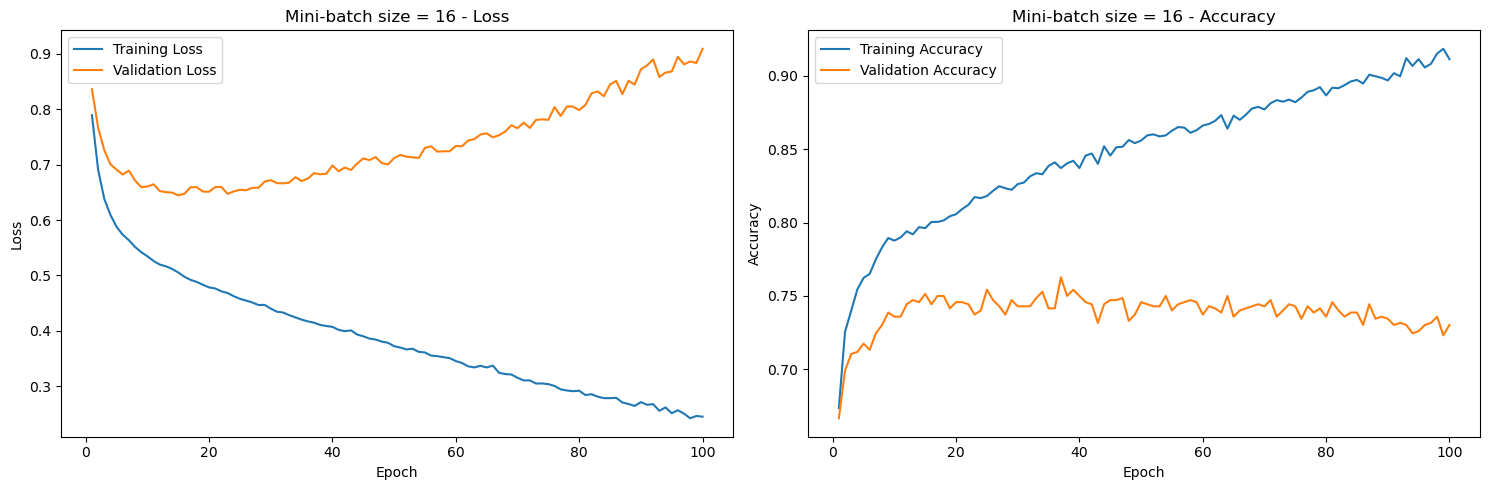

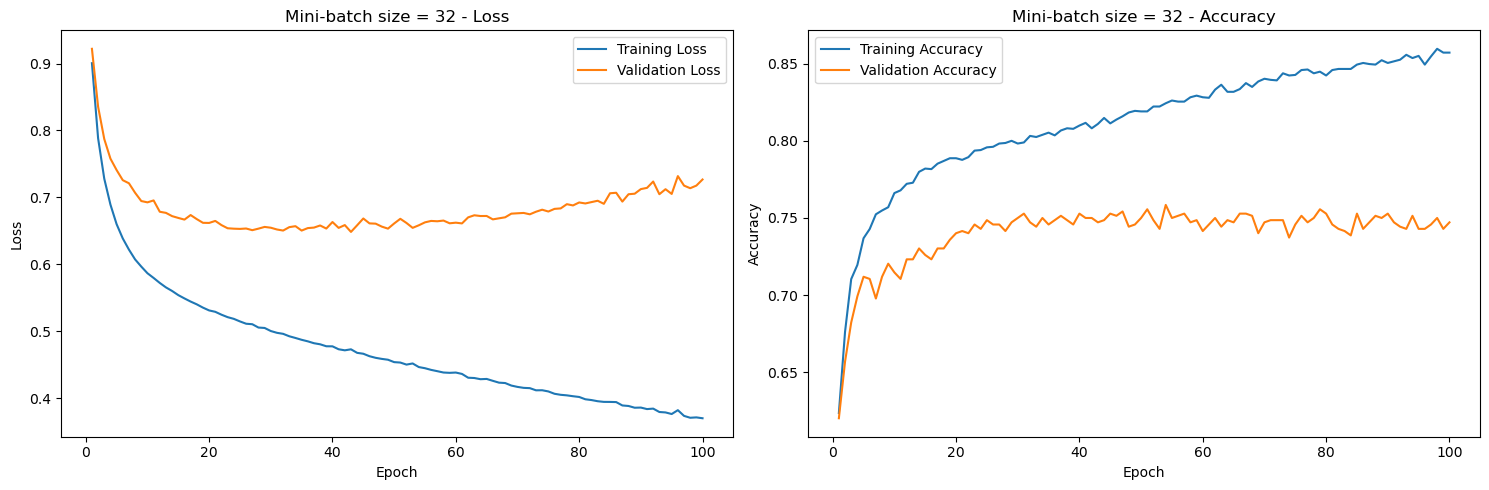

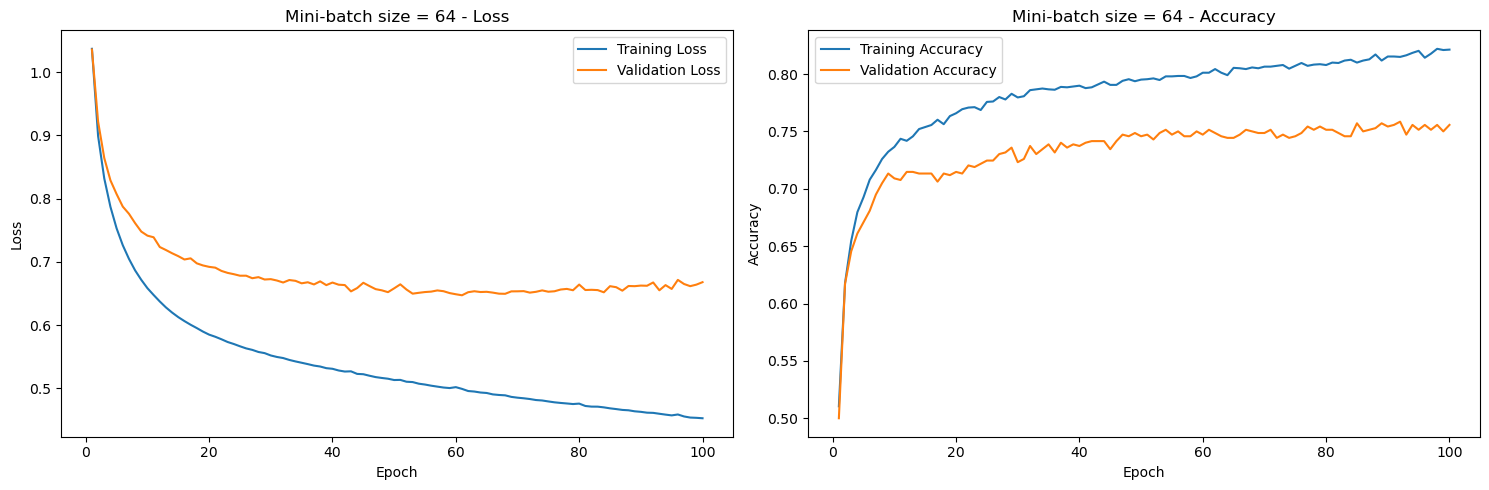

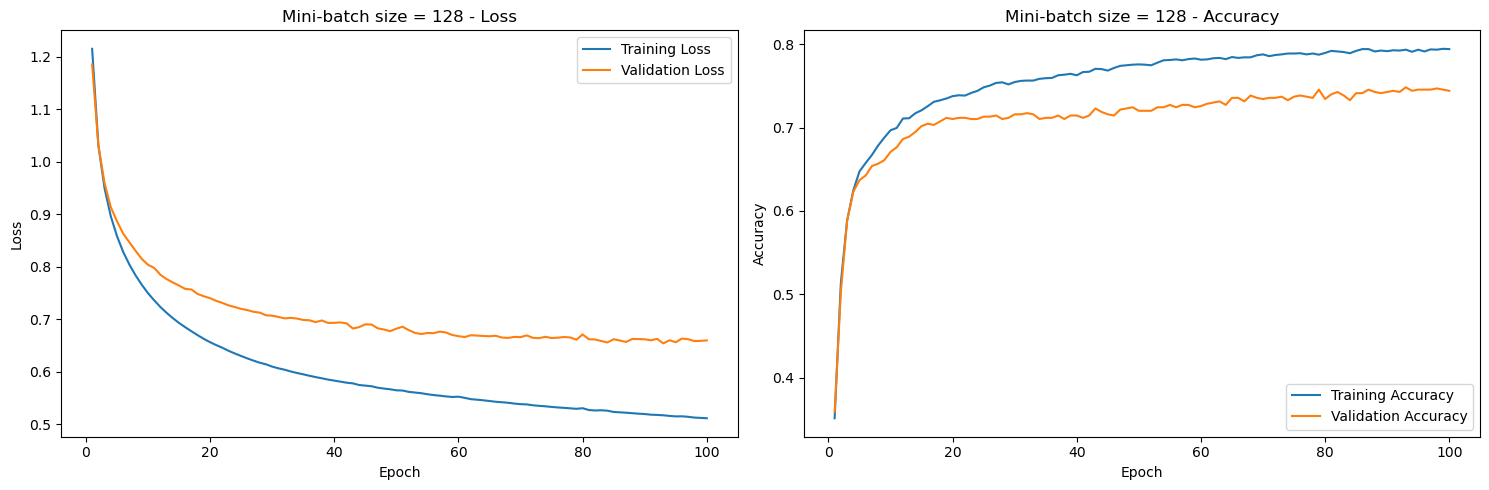

In [6]:
# Part C: Gradient Descent Variants

layer_sizes = [X_train.shape[1], 64, 32, 3]
epochs = 100
dropout_rate = 0.0

# Use He initialization as the default for the neural network
# Batch GD (batch_size = full training set)
params_batch, tl, vl, ta, va = train(X_train, y_train, X_val, y_val, layer_sizes, "he", 0.01, epochs, X_train.shape[0], dropout_rate)
plot_loss_and_acc(tl, vl, ta, va, "Batch GD")

# SGD (batch_size = 1)
params_sgd, tl, vl, ta, va = train(X_train, y_train, X_val, y_val, layer_sizes, "he", 0.01, epochs, 1, dropout_rate)
plot_loss_and_acc(tl, vl, ta, va, title = "SGD")

# Mini-batch GD
for bs in [16, 32, 64, 128]:
    params_mb, tl, vl, ta, va = train(X_train, y_train, X_val, y_val, layer_sizes, "he", 0.01, epochs, bs, dropout_rate)
    plot_loss_and_acc(tl, vl, ta, va, title = f"Mini-batch size = {bs}")

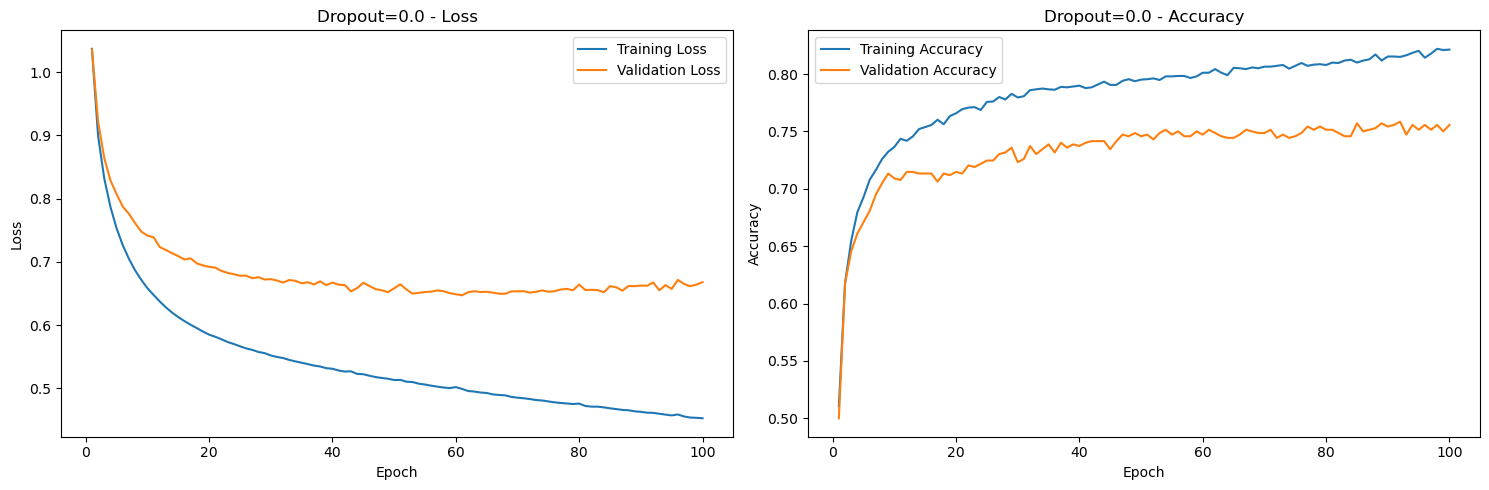

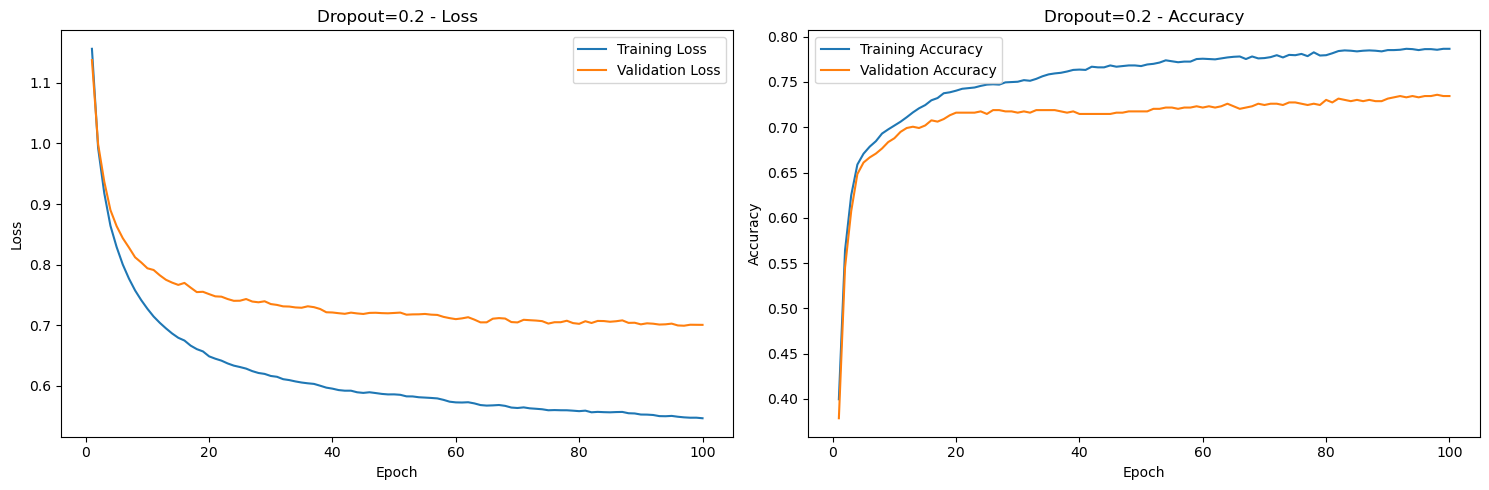

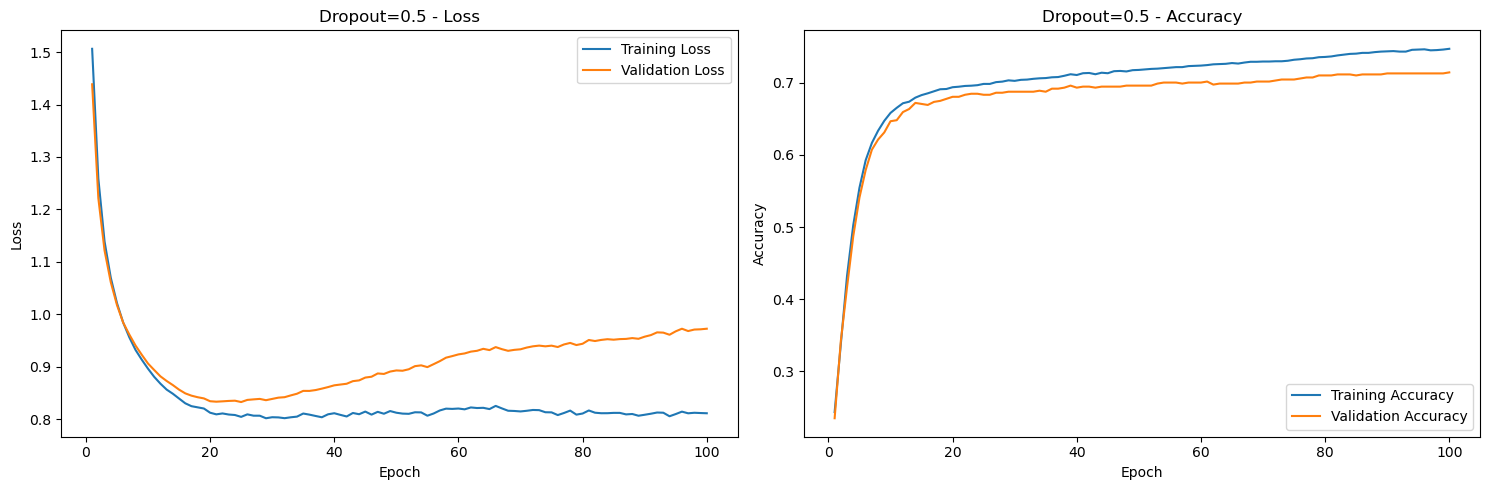

In [7]:
# Part D: Dropout Experiments

dropout_rates = [0.0, 0.2, 0.5]

for rate in dropout_rates:
    # Use He initialization as the default for the neural network
    params, tl, vl, ta, va = train(X_train, y_train, X_val, y_val, layer_sizes, "he", 0.01, epochs, 64, rate)
    plot_loss_and_acc(tl, vl, ta, va, f"Dropout={rate}")

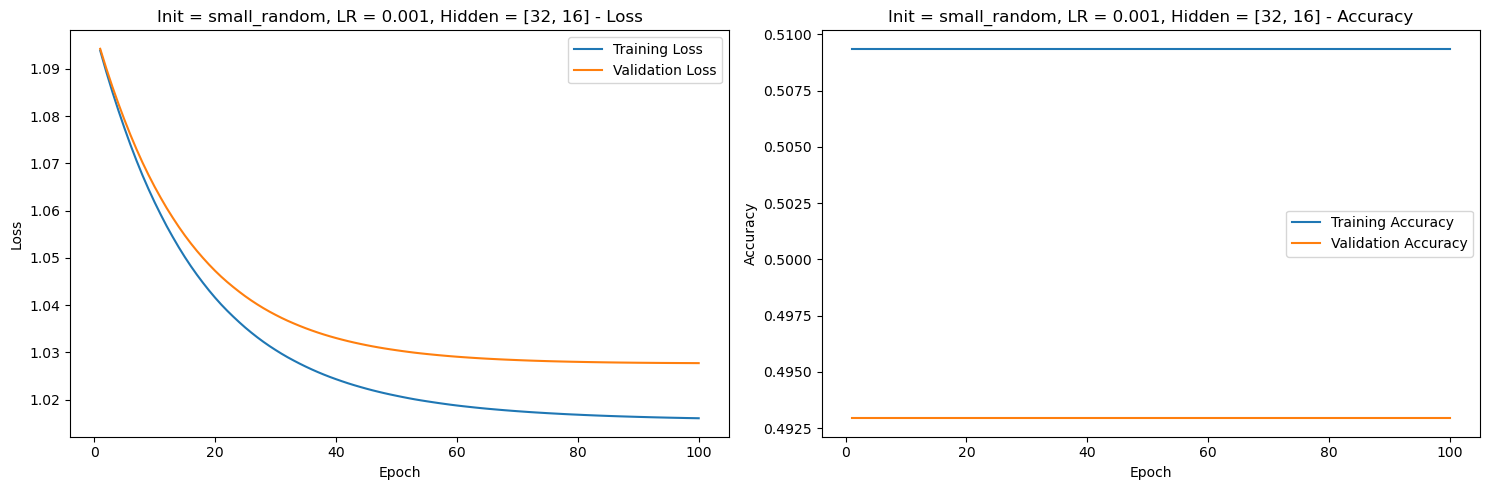

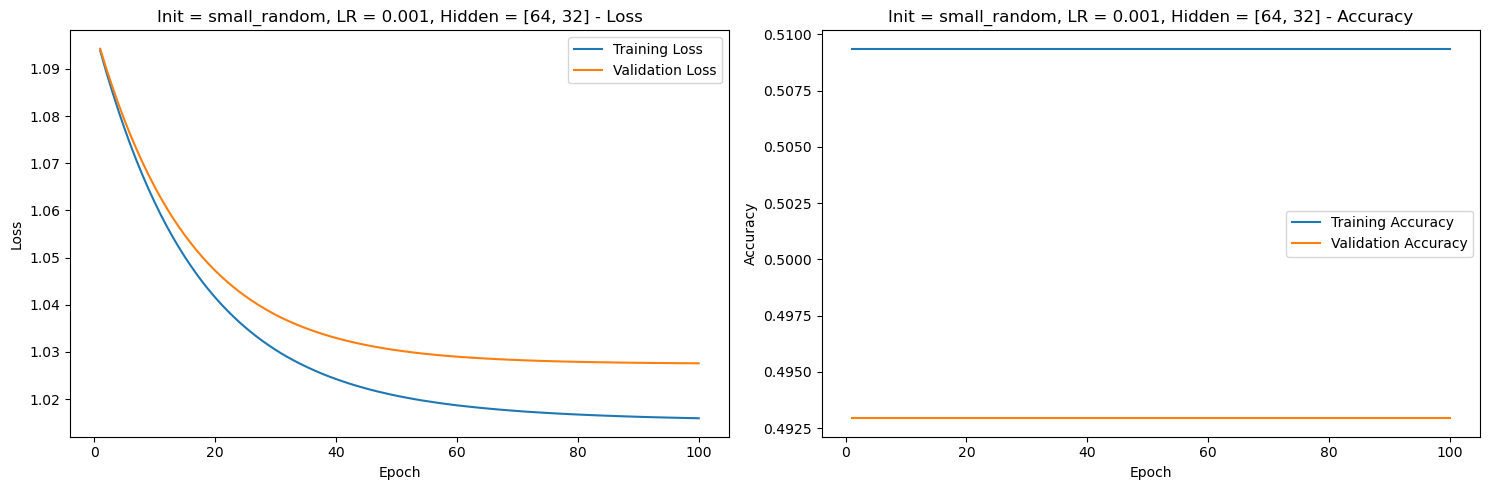

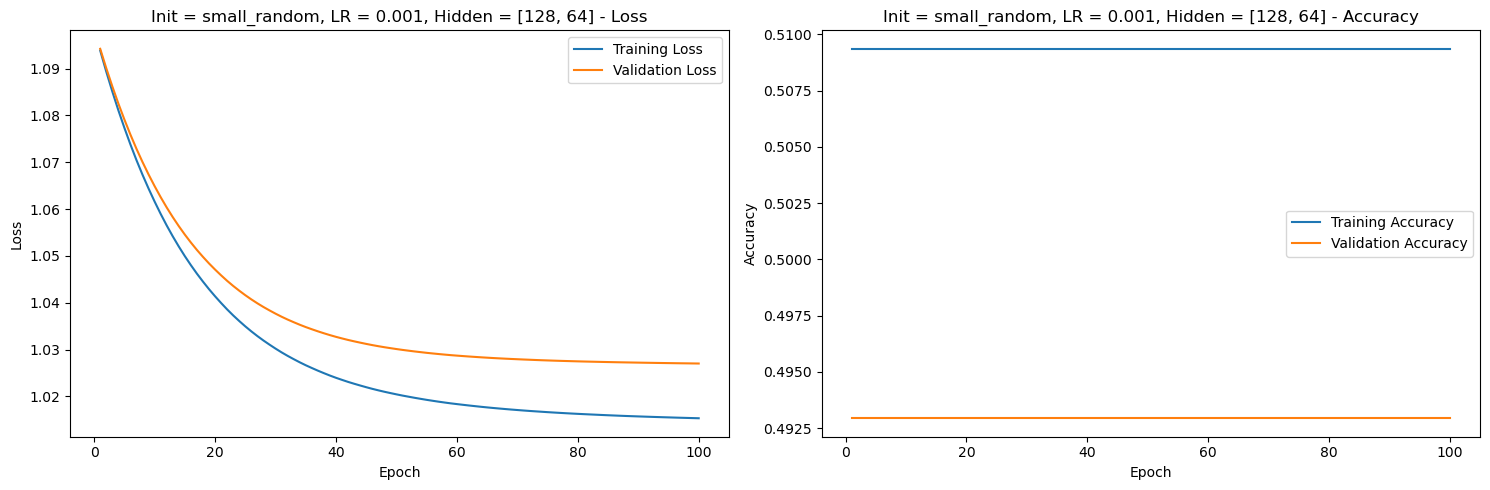

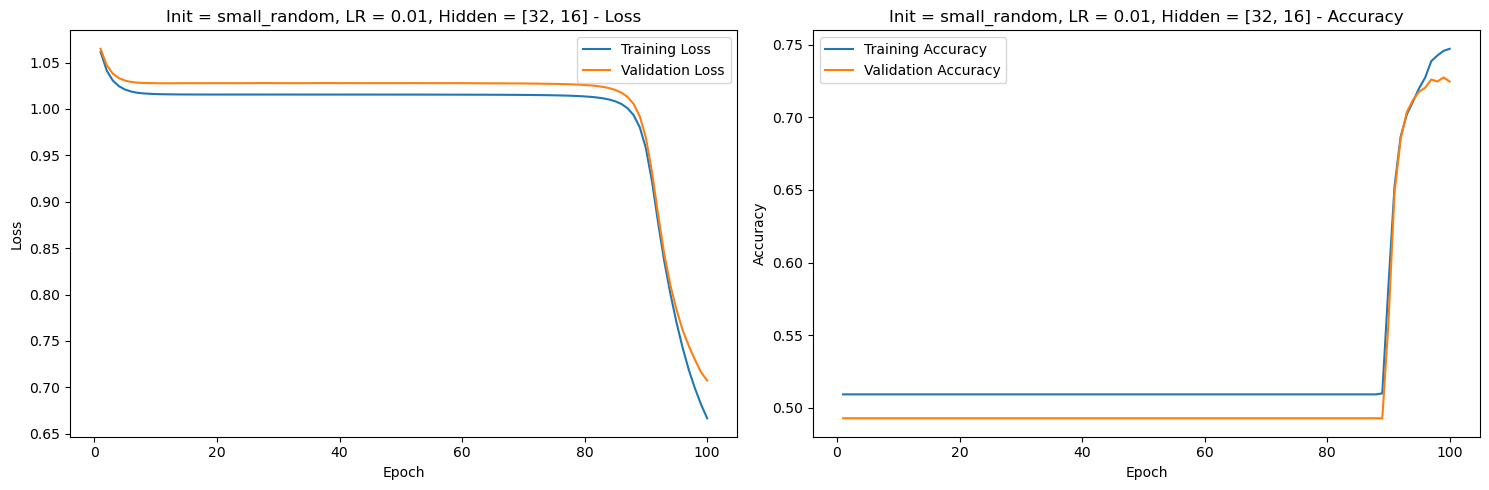

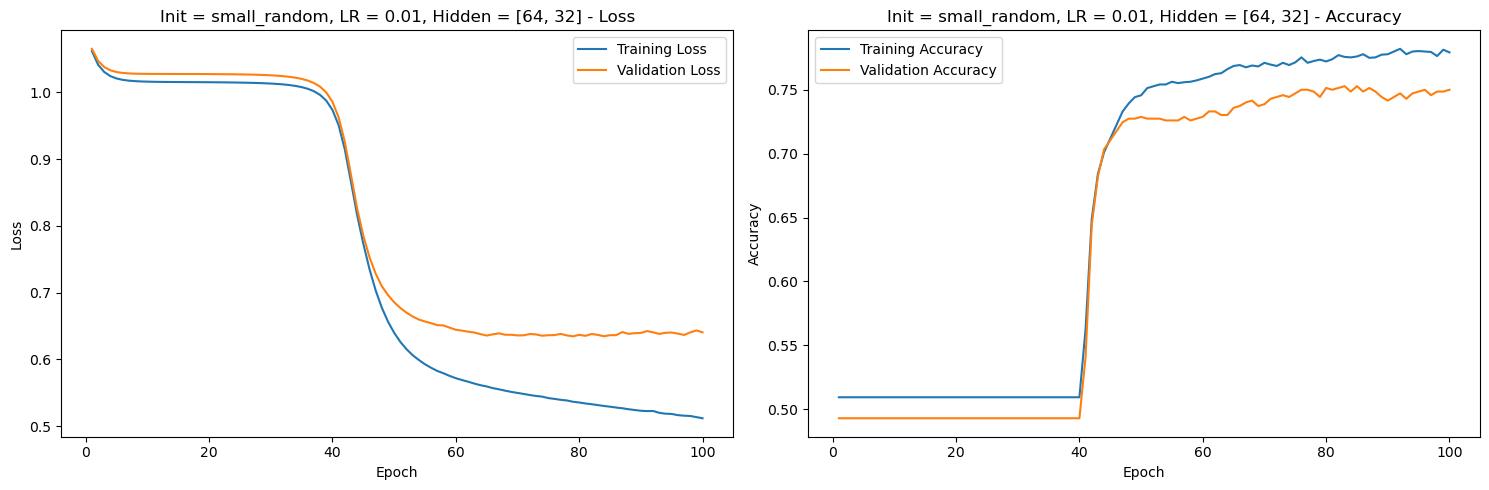

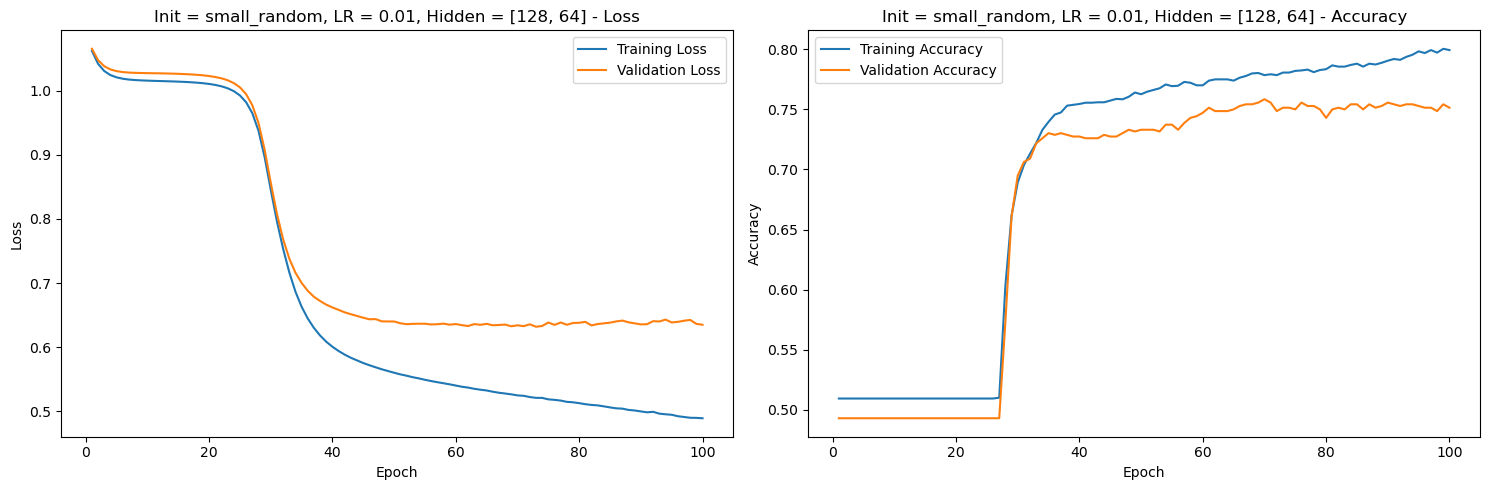

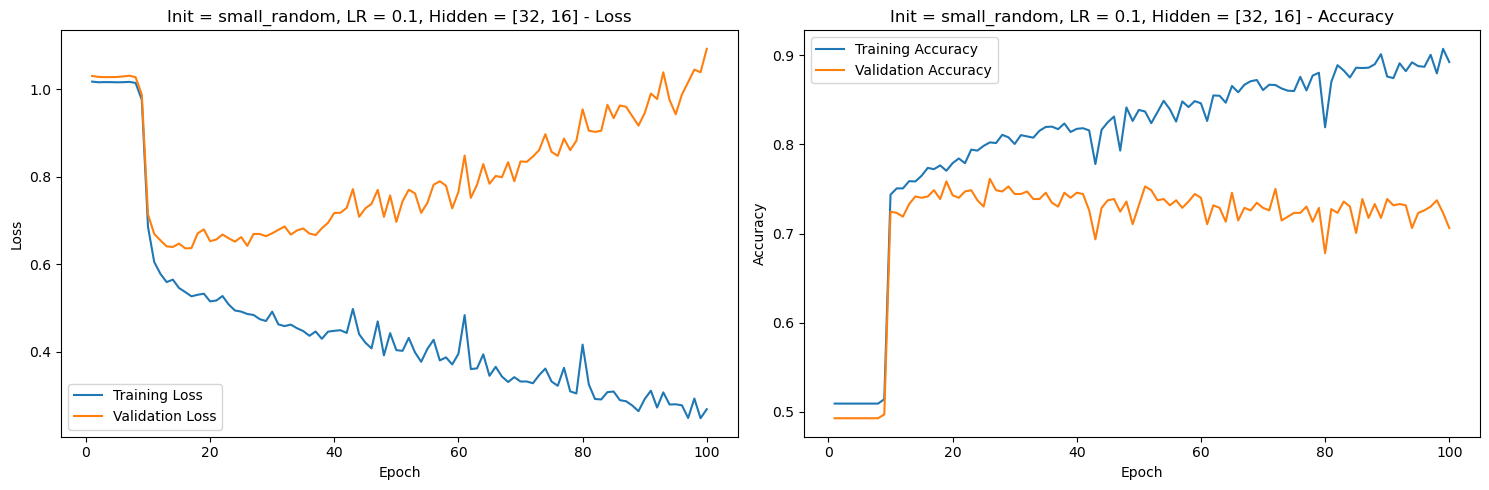

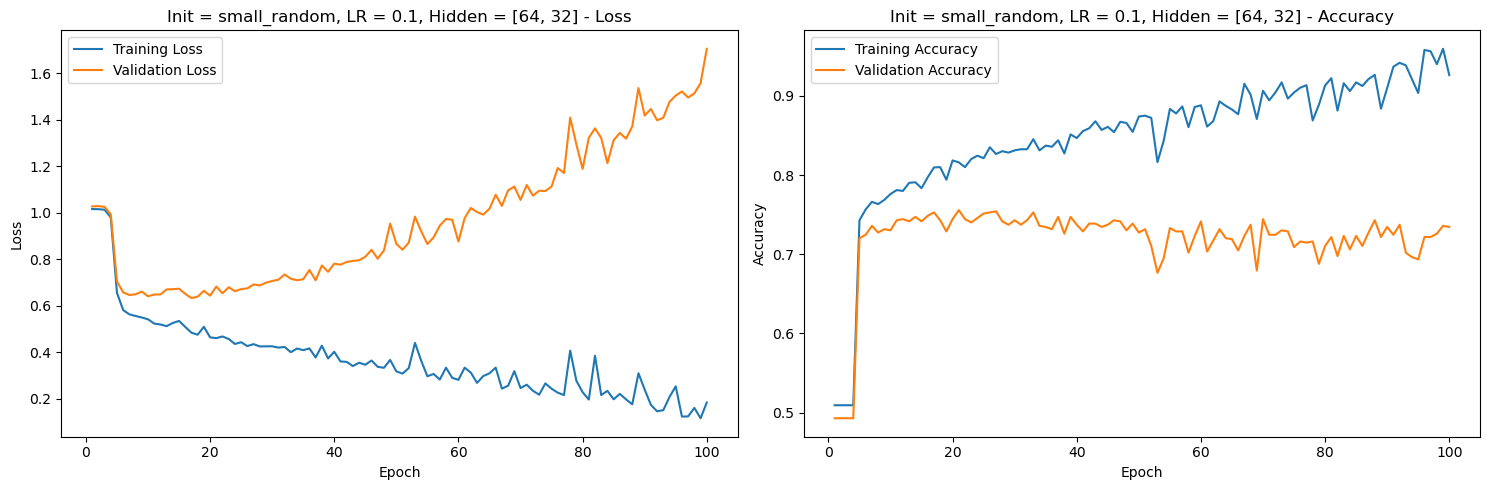

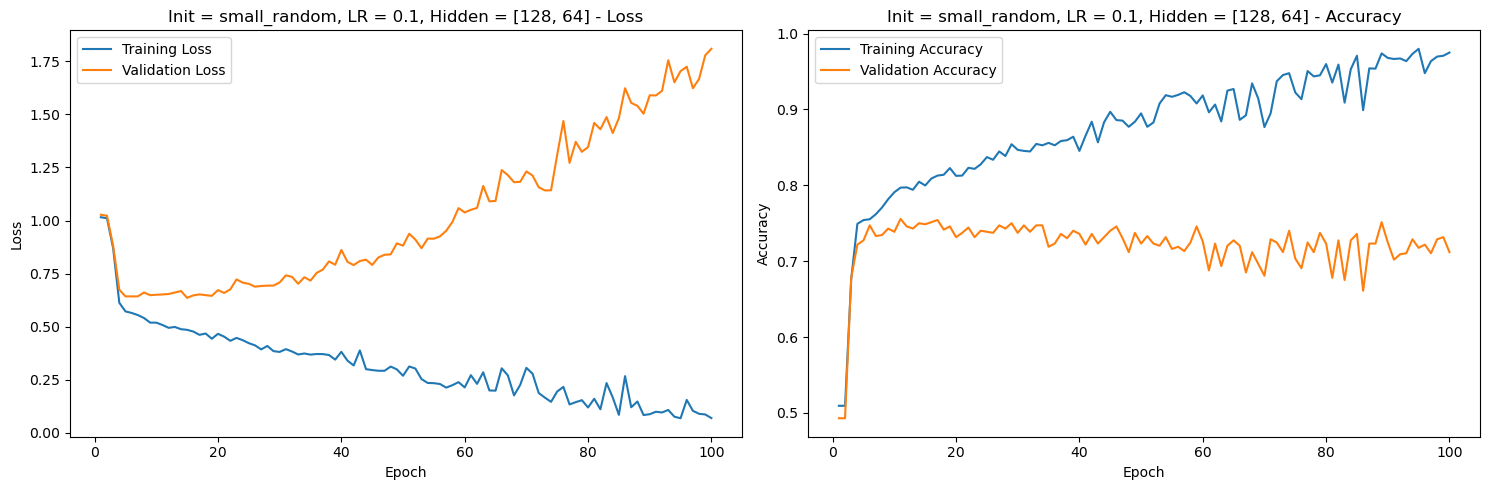

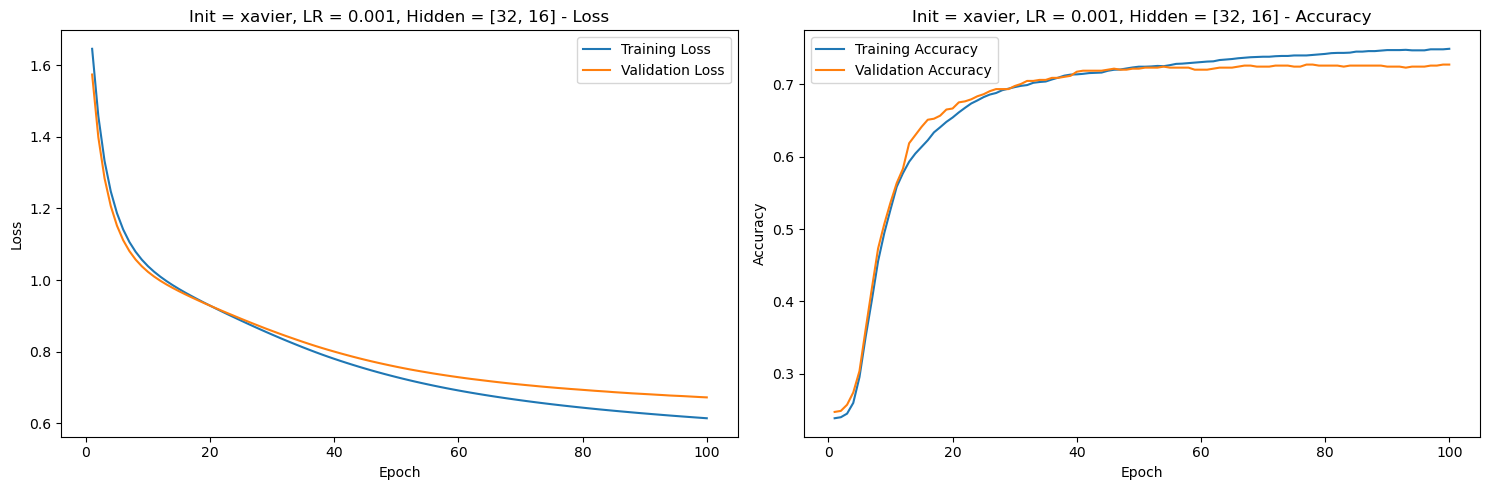

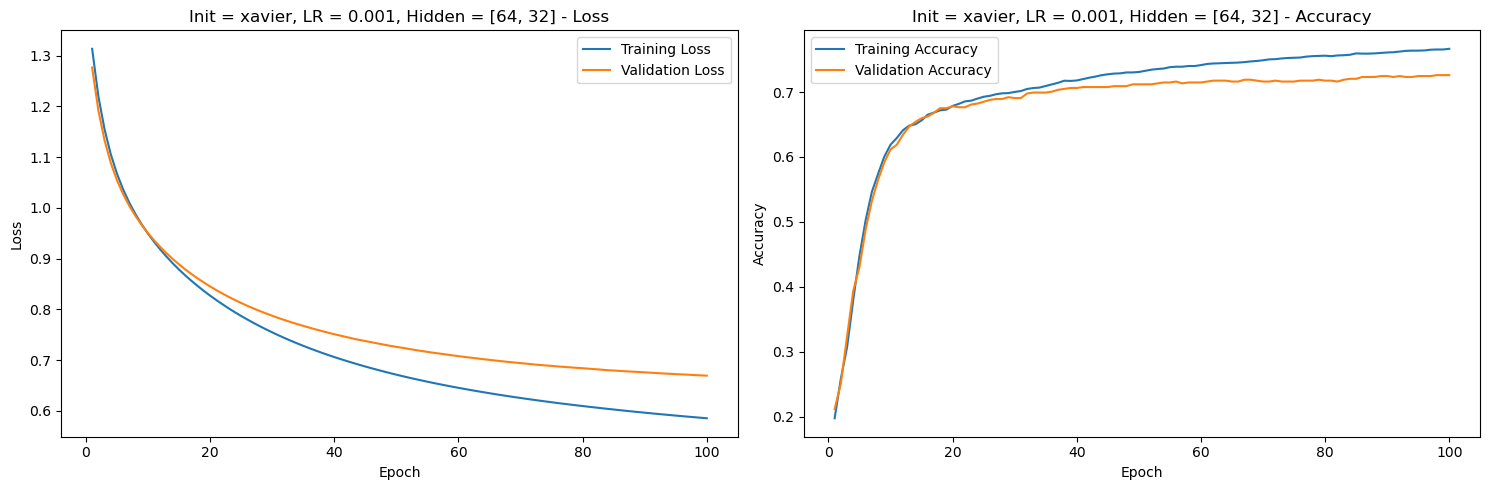

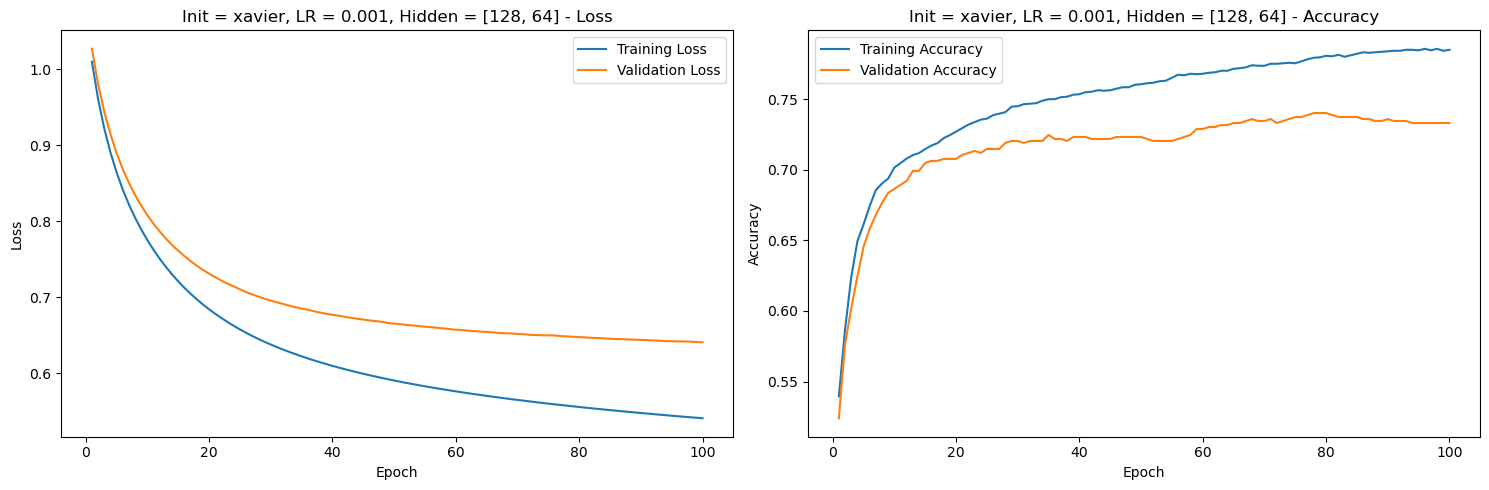

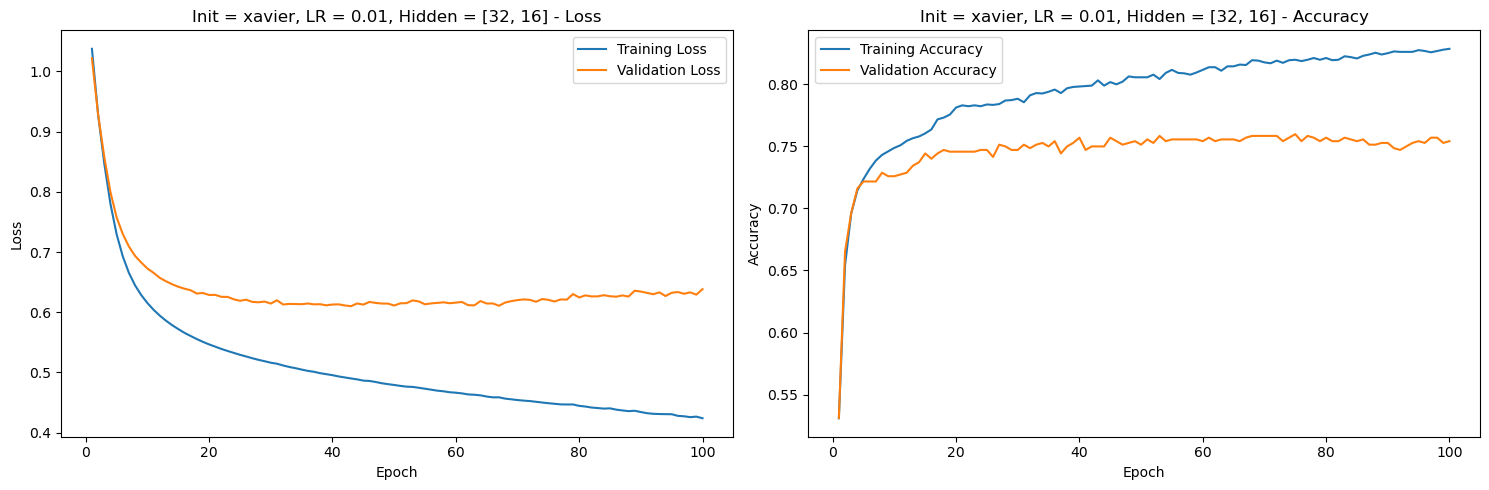

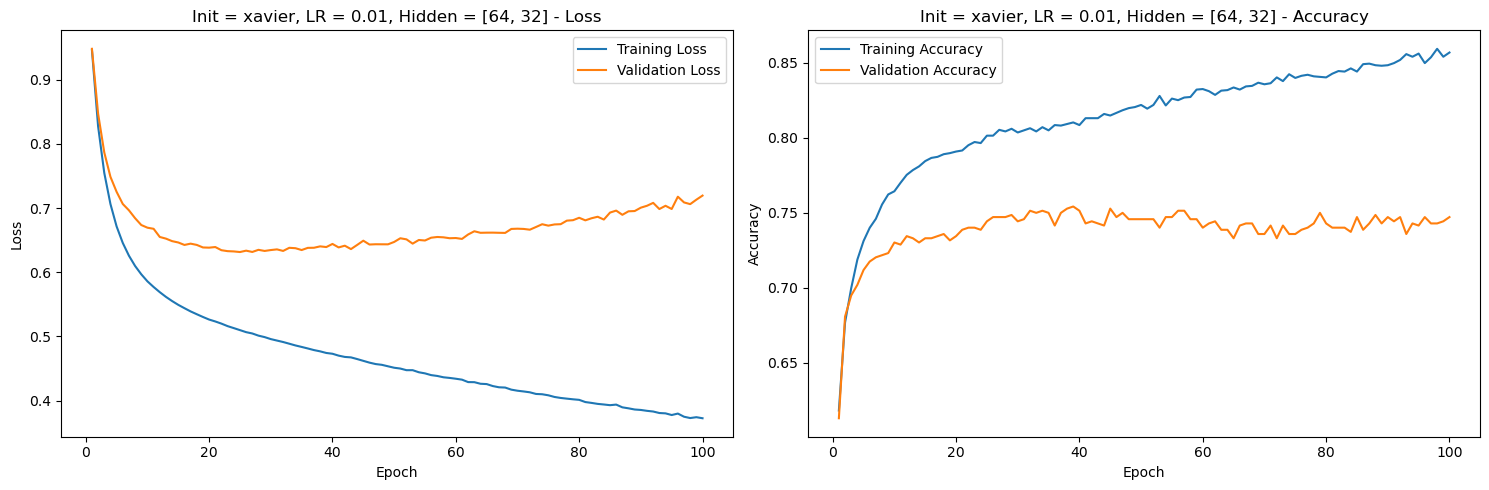

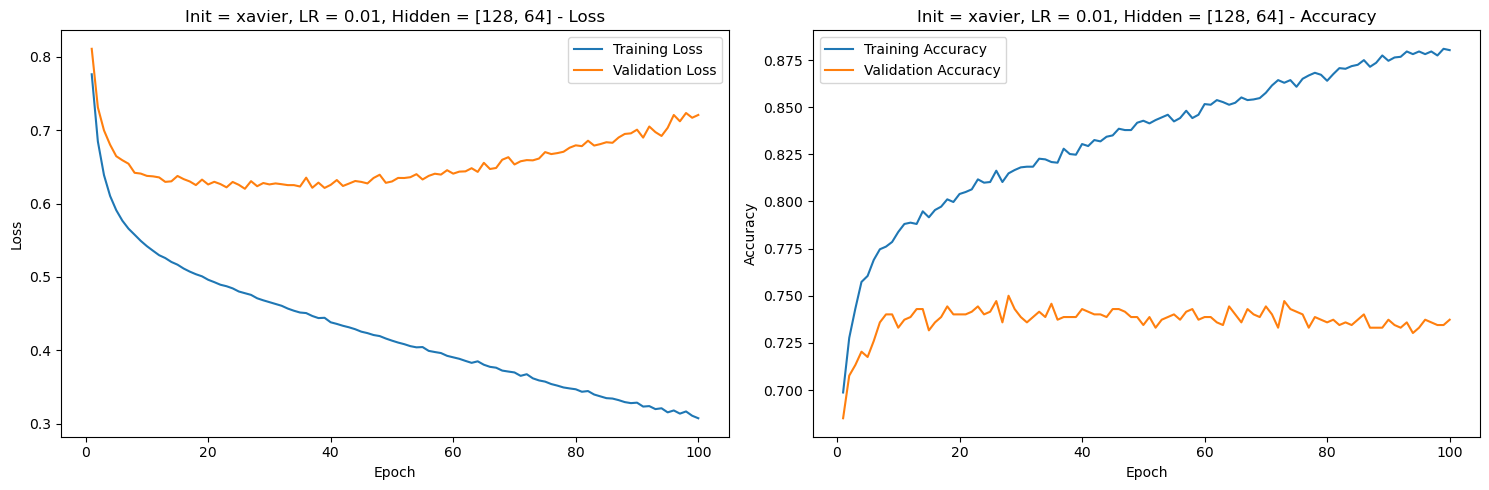

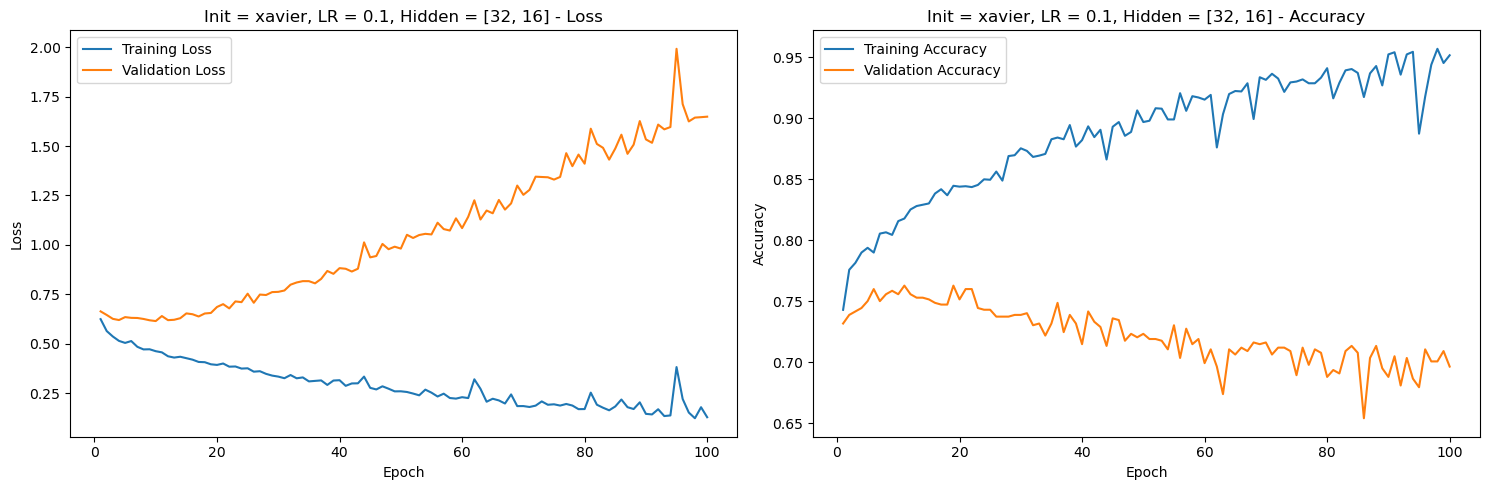

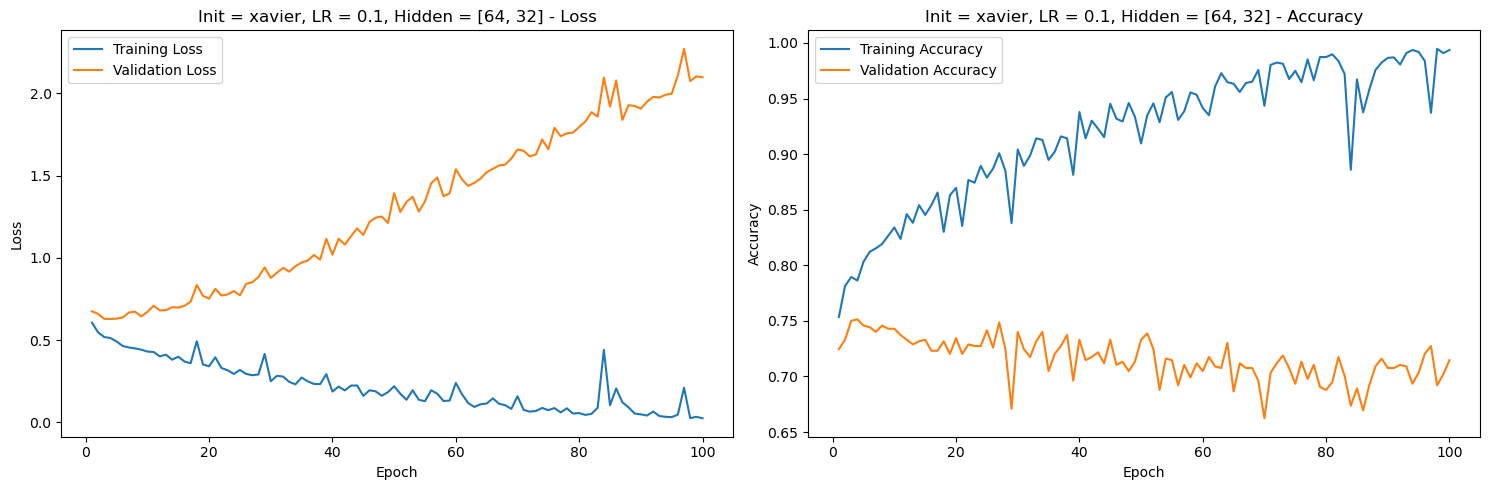

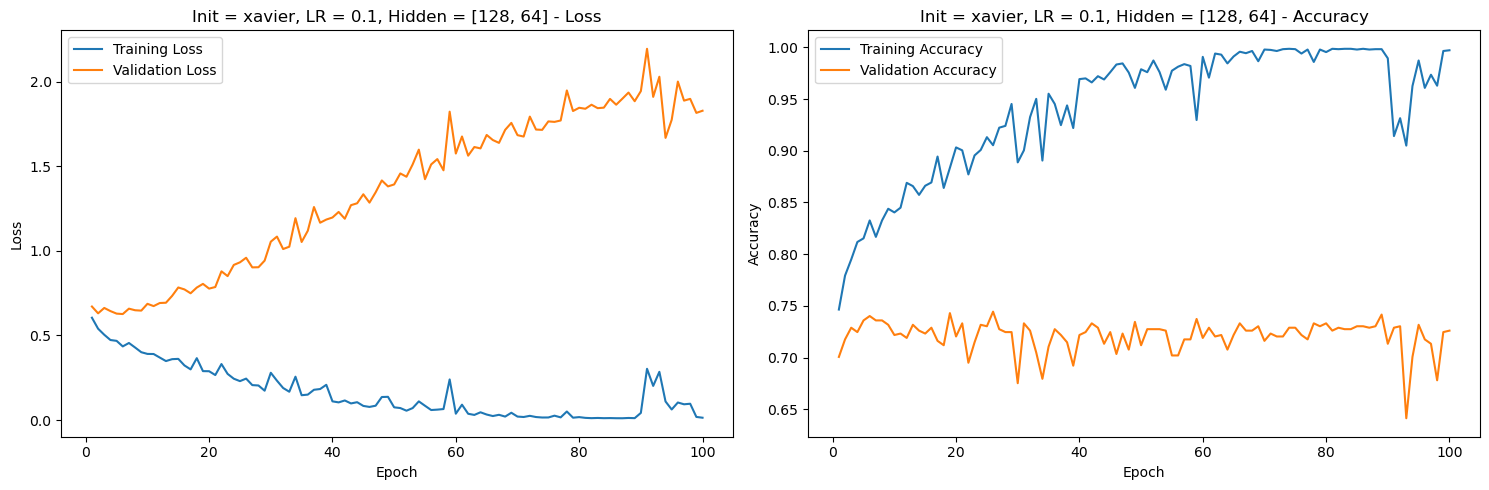

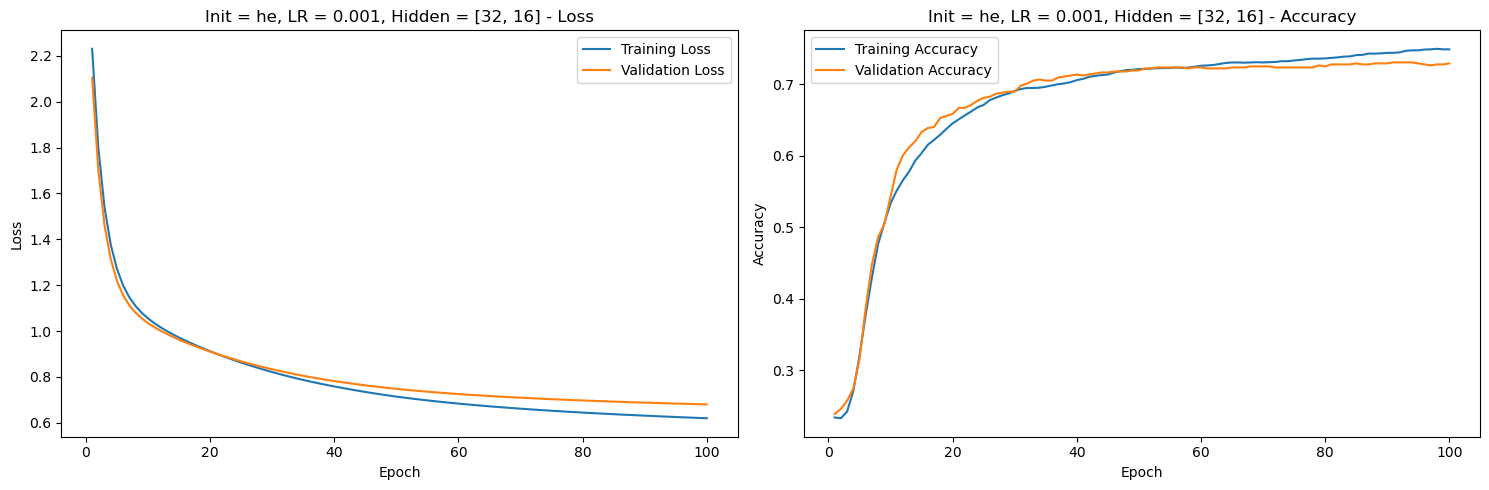

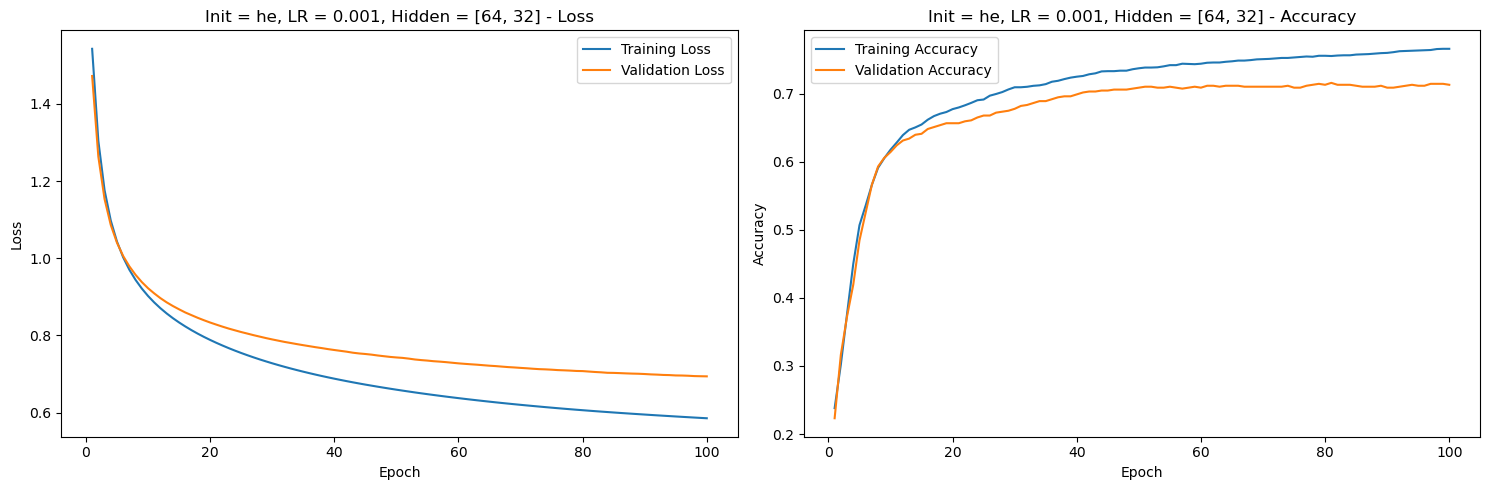

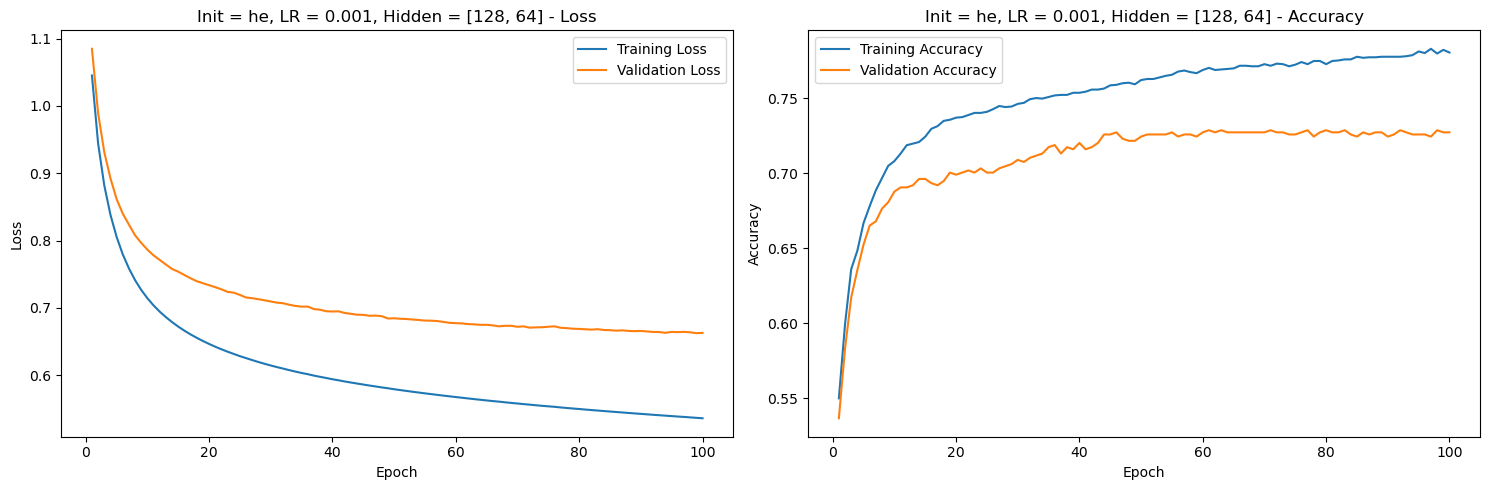

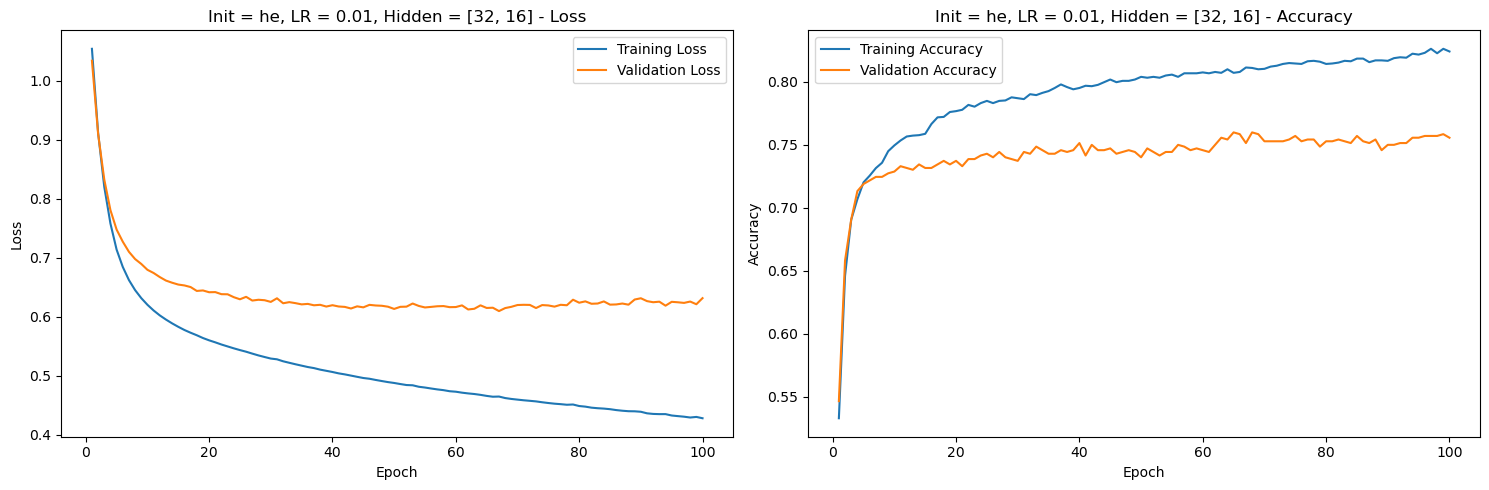

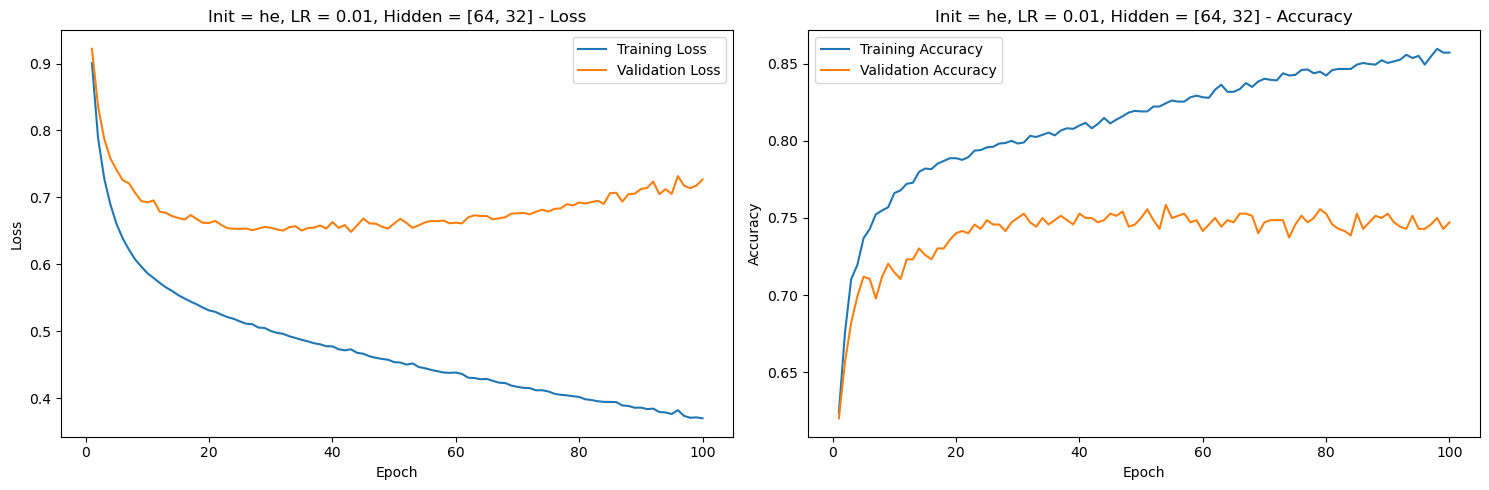

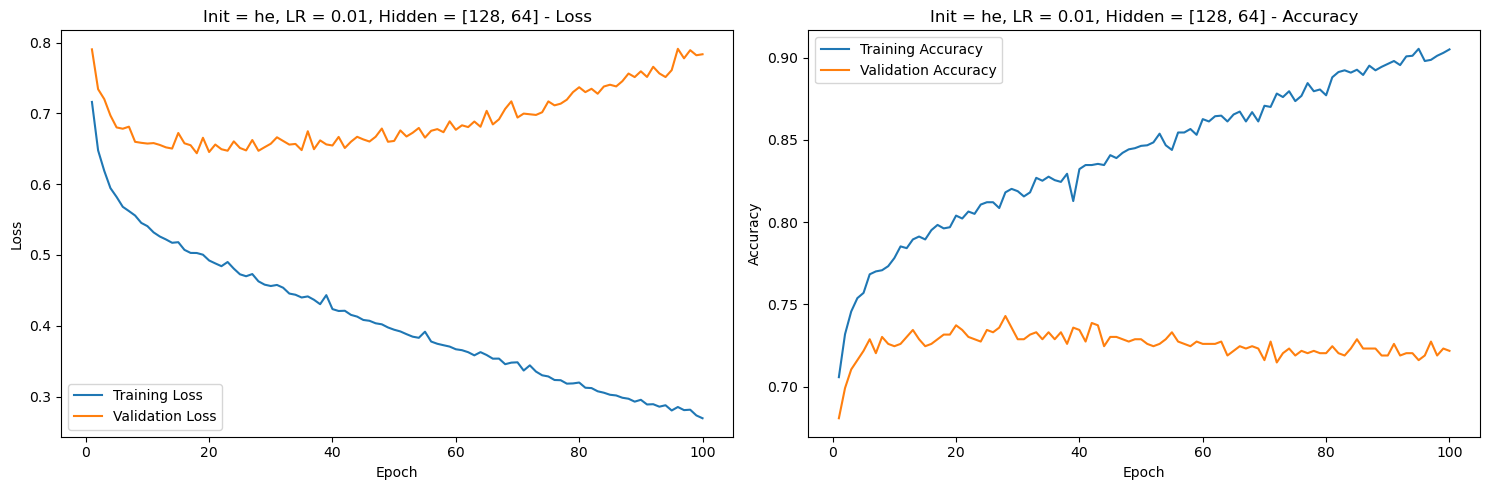

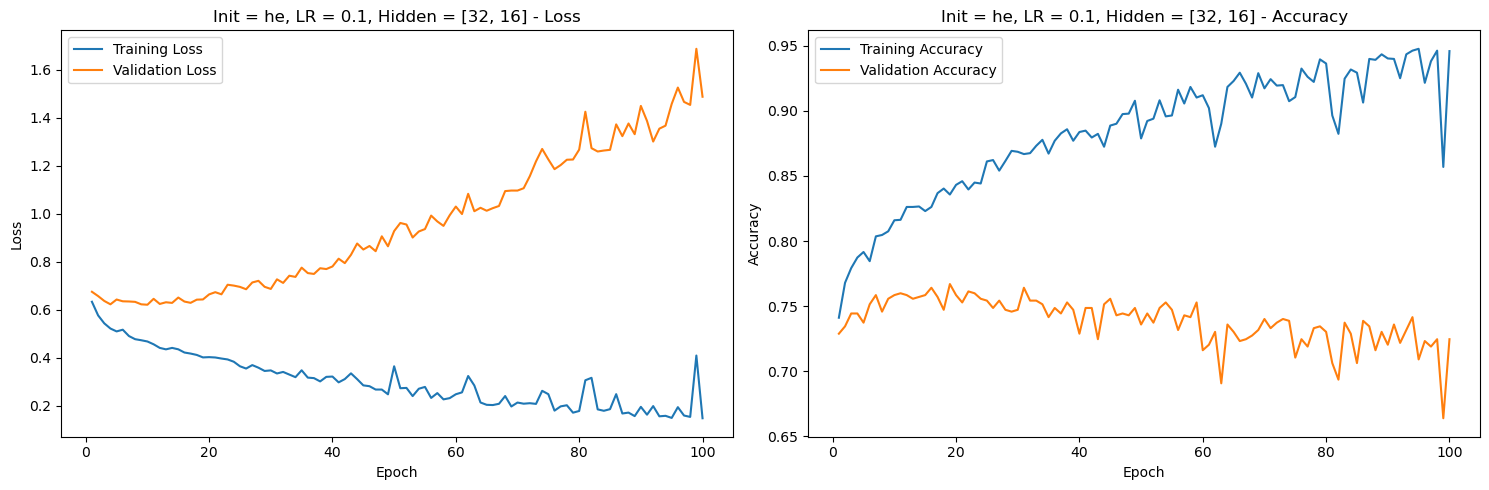

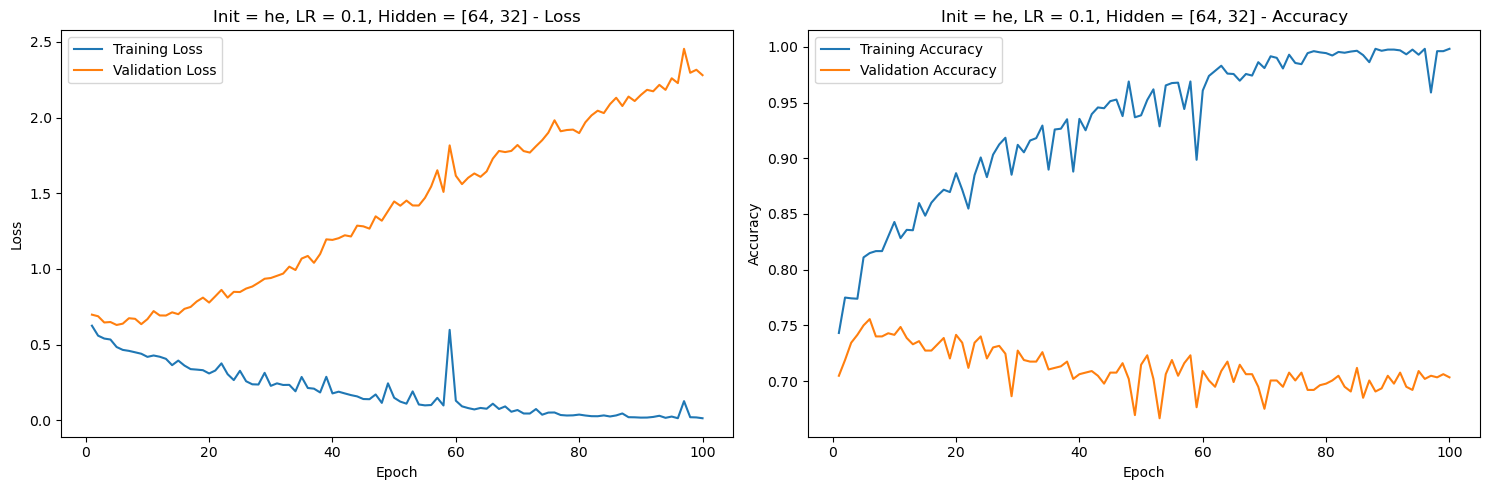

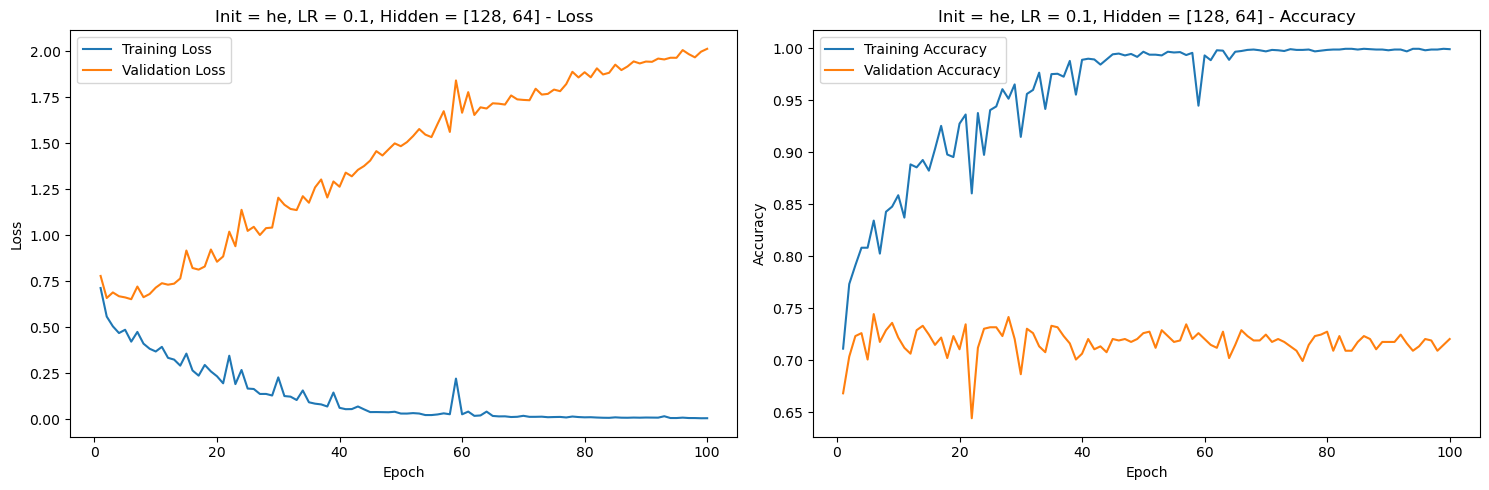

In [8]:
# Part E: Weight Initialization and Hyperparameter Experiments

init_types = ["small_random", "xavier", "he"]
learning_rates = [0.001, 0.01, 0.1]
hidden_configs = [
    [32, 16],
    [64, 32],
    [128, 64]
]

for init_type in init_types:
    for lr in learning_rates:
        for hidden in hidden_configs:
            layer_sizes_experiment = [X_train.shape[1]] + hidden + [3]
            params, tl, vl, ta, va = train(X_train, y_train, X_val, y_val, layer_sizes_experiment, init_type, lr, epochs, 32, 0.0)
            plot_loss_and_acc(tl, vl, ta, va, f"Init = {init_type}, LR = {lr}, Hidden = {hidden}")

In [9]:
# Part F: Experimental Results Table

results = []

experiments = [
    # (optimizer, dropout, init, lr, hidden, batch_size)
    # 3 gradient descent variants
    ("Batch GD", 0.0, "he", 0.01, [64, 32], X_train.shape[0]),
    ("SGD", 0.0, "he", 0.01, [64, 32], 1),
    ("Mini-batch", 0.0, "he", 0.01, [64, 32], 32),
    # 3 dropout rates
    ("Mini-batch", 0.0, "he", 0.01, [64, 32], 32),
    ("Mini-batch", 0.2, "he", 0.01, [64, 32], 32),
    ("Mini-batch", 0.5, "he", 0.01, [64, 32], 32),
    # 3 initialization strategies
    ("Mini-batch", 0.0, "small_random", 0.01, [64, 32], 32),
    ("Mini-batch", 0.0, "xavier", 0.01, [64, 32], 32),
    ("Mini-batch", 0.0, "he", 0.01, [64, 32], 32),
    # 3 learning rates
    ("Mini-batch", 0.0, "he", 0.001, [64, 32], 32),
    ("Mini-batch", 0.0, "he", 0.01,  [64, 32], 32),
    ("Mini-batch", 0.0, "he", 0.1,   [64, 32], 32),
    # 2 hidden layer configurations
    ("Mini-batch", 0.0, "he", 0.01, [32, 16],  32),
    ("Mini-batch", 0.0, "he", 0.01, [128, 64], 32),
]

for optimizer, dropout, init, lr, hidden, batch_size in experiments:
    layer_sizes_experiment = [X_train.shape[1]] + hidden + [3]
    params, tl, vl, ta, va = train(X_train, y_train, X_val, y_val, layer_sizes_experiment, init, lr, epochs, batch_size, dropout)
    
    test_preds = predict(X_test, params)
    test_acc = accuracy(test_preds, y_test)

    results.append({
        "Optimizer": optimizer,
        "Dropout": dropout,
        "Init": init,
        "LR": lr,
        "Hidden": str(hidden),
        "Batch": batch_size,
        "Training Accuracy": round(ta[-1], 4),
        "Validation Accuracy": round(va[-1], 4),
        'Test Accuracy': round(test_acc, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index = False))

 Optimizer  Dropout         Init    LR    Hidden  Batch  Training Accuracy  Validation Accuracy  Test Accuracy
  Batch GD      0.0           he 0.010  [64, 32]   2831             0.6305               0.6271         0.6271
       SGD      0.0           he 0.010  [64, 32]      1             0.9968               0.6992         0.7243
Mini-batch      0.0           he 0.010  [64, 32]     32             0.8573               0.7472         0.7412
Mini-batch      0.0           he 0.010  [64, 32]     32             0.8573               0.7472         0.7412
Mini-batch      0.2           he 0.010  [64, 32]     32             0.8022               0.7472         0.7559
Mini-batch      0.5           he 0.010  [64, 32]     32             0.7616               0.7274         0.7412
Mini-batch      0.0 small_random 0.010  [64, 32]     32             0.7792               0.7500         0.7458
Mini-batch      0.0       xavier 0.010  [64, 32]     32             0.8569               0.7472         0.7571
M